# Loading the Data set

In [18]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)
print("Files in directory:", os.listdir(path))
csv_file_path = os.path.join(path, "insurance.csv")

Path to dataset files: /home/nothing/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1
Files in directory: ['insurance.csv']


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv(csv_file_path)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [22]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [24]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'])

In [26]:
df.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='str')

In [25]:
X = df.drop(columns='charges').values
y = df['charges'].values

print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (1338, 11)
Shape of y:  (1338,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Shape of X_train: ', X_train.shape)
print('Shape of X_test: ', X_test.shape)
print('Shape of y_train: ', y_train.shape)
print('Shape of y_test: ', y_test.shape)

Shape of X_train:  (1070, 11)
Shape of X_test:  (268, 11)
Shape of y_train:  (1070,)
Shape of y_test:  (268,)


In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 256.98, 337.09, 425.28,..., 88.91,-198.28,-350.21]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-574.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[460.89,195.95, 39.69,..., 0. , 0. , 0. ]"


In [30]:
print(model.coef_)
print(model.intercept_)


[ 2.56975706e+02  3.37092552e+02  4.25278784e+02  9.29584582e+00
 -9.29584582e+00 -1.18255644e+04  1.18255644e+04  4.59585244e+02
  8.89079180e+01 -1.98279052e+02 -3.50214110e+02]
-574.5357125101964


In [31]:
model.score(X_test, y_test)

0.7835929767120722

In [32]:
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)

33596915.851361476

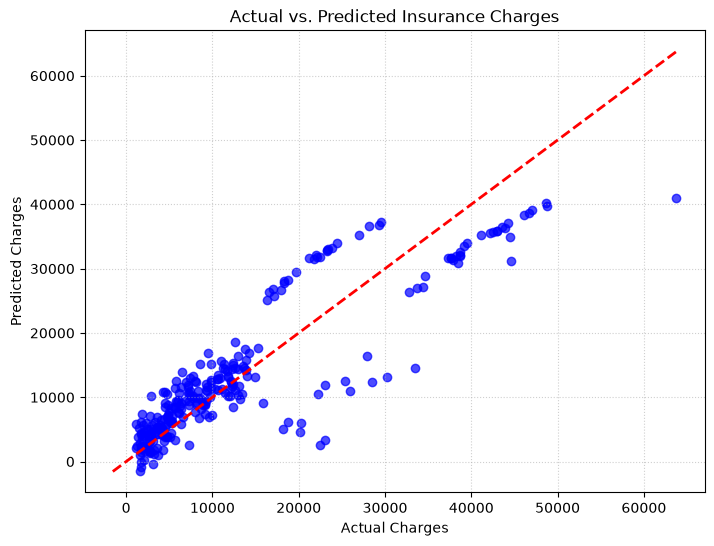

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Insurance Charges')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

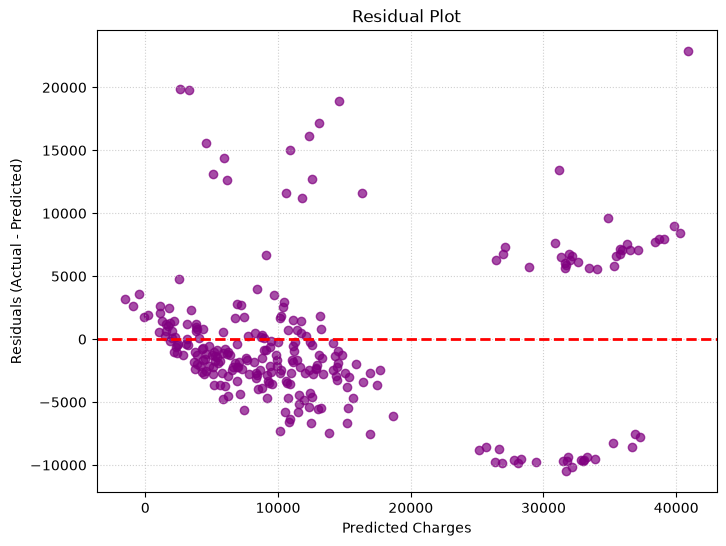

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [38]:
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1

lower_bound_y = Q1 - 1.5 * IQR
upper_bound_y = Q3 + 1.5 * IQR

outliers_y = (y_train < lower_bound_y) | (y_train > upper_bound_y)

In [40]:
mask = ~outliers_y
X_train = X_train[mask]
y_train = y_train[mask]

In [42]:
print(X_train.shape)
print(y_train.shape)

(959, 11)
(959,)


In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model_2 = LinearRegression()
model_2.fit(X_train_scaled, y_train)

r2_model_2 = model_2.score(X_test_scaled, y_test)
y_pred_2 = model_2.predict(X_test_scaled)
mse_model_2 = mean_squared_error(y_test, y_pred_2)

print(f"Model 2 R2 Score: {r2_model_2}")
print(f"Model 2 MSE: {mse_model_2}")

Model 2 R2 Score: 0.6396505813739772
Model 2 MSE: 55943790.1354881


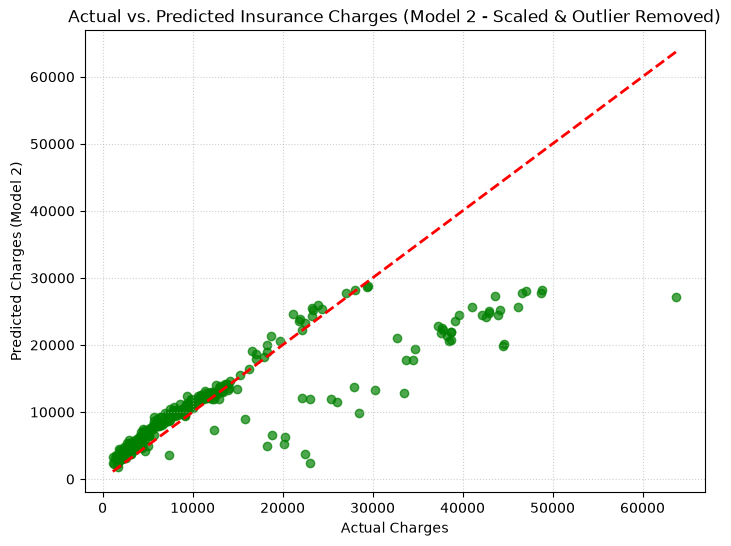

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_2, alpha=0.7, color='green')
min_val = min(min(y_test), min(y_pred_2))
max_val = max(max(y_test), max(y_pred_2))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges (Model 2)')
plt.title('Actual vs. Predicted Insurance Charges (Model 2 - Scaled & Outlier Removed)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

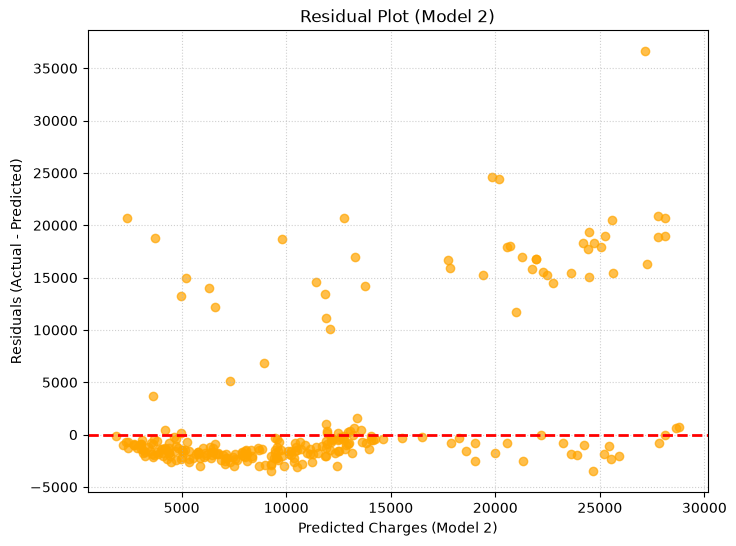

In [47]:
residuals_2 = y_test - y_pred_2

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_2, residuals_2, alpha=0.7, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted Charges (Model 2)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Model 2)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### **15. Model Comparison**

* **Which model has the higher $R^2$?** Model 1 ($\approx 0.783$ vs. $\approx 0.640$).
* **Which model has the lower MSE?** Model 1 ($\approx 33.6\text{M}$ vs. $\approx 55.9\text{M}$).
* **Did outlier removal and feature scaling improve the results?** No. Removing high-end charges truncated the target range, and feature scaling does not alter OLS linear regression performance.
* **Which model would you choose?** Model 1, because retaining the full data range provides better overall predictive accuracy across all cost tiers.

---

### **16. Code Comments & Summary Explanation**

* **Categorical Encoding:** Converted `sex`, `smoker`, and `region` into binary columns using one-hot encoding (`pd.get_dummies`) for numeric compatibility.
* **Outlier Removal:** Applied the IQR method strictly to `y_train` to prevent data leakage. Dropping high-end charges reduced performance, showing extreme medical costs are valid patterns (e.g., smoking effects) rather than errors.
* **Feature Scaling:** Applied `StandardScaler` fitted exclusively on `X_train` and transformed onto `X_test` to prevent data leakage while maintaining proper model workflows.